In [ ]:
pip install gwaslab 


Defaulting to user installation because normal site-packages is not writeable


Note: you may need to restart the kernel to use updated packages.


In [1]:
import gwaslab as gl
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

## Load gwas data

In [2]:
import pandas as pd
import gzip

file_path = "../../data/susie/UK_Biobank/UKBB_HI_CHOL.sumstats.gz"
with gzip.open(file_path, 'rt') as f:
    gwas_data_df_col = pd.read_csv(f, sep='\t') 

In [3]:
gwas_data_df_col.head(10)

,SNP,A1,A2,Z,N
0,rs3094315,G,A,1.254,459324.0
1,rs3131972,A,G,1.200,459324.0
2,rs3131969,A,G,2.212,459324.0
3,rs1048488,C,T,1.341,459324.0
4,rs3115850,T,C,1.311,459324.0
5,rs2286139,C,T,2.170,459324.0
6,rs12562034,G,A,3.156,459324.0
7,rs4040617,A,G,-1.977,459324.0
8,rs2980300,T,C,2.034,459324.0
9,rs2519031,NaN,NaN,NaN,NaN


In [17]:
import pandas as pd
import gzip

file_path = "../../data/susie/UK_Biobank/UKBB_Type_2_Diabetes.sumstats.gz"
with gzip.open(file_path, 'rt') as f:
    gwas_data_df_t2d = pd.read_csv(f, sep='\t') 

In [19]:
gwas_data_df_t2d.head(10)

,SNP,A1,A2,Z,N
0,rs3094315,G,A,-0.583,459324.0
1,rs3131972,A,G,-0.539,459324.0
2,rs3131969,A,G,-0.954,459324.0
3,rs1048488,C,T,-0.772,459324.0
4,rs3115850,T,C,-0.755,459324.0
5,rs2286139,C,T,-1.015,459324.0
6,rs12562034,G,A,-0.524,459324.0
7,rs4040617,A,G,1.058,459324.0
8,rs2980300,T,C,-0.896,459324.0
9,rs2519031,NaN,NaN,NaN,NaN


## Data Processing 

In [4]:
gwas_data_df["SNPID"] = gwas_data_df["CHR"].astype(str) + ":" + gwas_data_df["POS"].astype(str) + ":" + gwas_data_df["A1"] + ":" + gwas_data_df["A2"]


In [5]:
gwas_data_df.head()

,SNP,CHR,POS,A1,A2,REF,EAF,Beta,se,P,N,INFO,SNPID
0,rs10399793,1,49298,T,C,T,0.376220,0.000334,0.000732,0.700,459324,0.342797,1:49298:T:C
1,rs2462492,1,54676,C,T,C,0.599409,-0.000938,0.000725,0.170,459324,0.340158,1:54676:C:T
2,rs3107975,1,55326,T,C,T,0.991552,0.007068,0.004034,0.083,459324,0.324228,1:55326:T:C
3,rs74447903,1,57033,T,C,T,0.998221,0.009198,0.008976,0.380,459324,0.296256,1:57033:T:C
4,1:70728_C_T,1,70728,C,T,C,0.997834,0.008596,0.007304,0.260,459324,0.365713,1:70728:C:T


## Minor Allele Frequency and Significant SNP Filtering 

In [ ]:
significant_snp_df = gwas_data_df[gwas_data_df['P'] <= 5e-8]
significant_snp_df = significant_snp_df[~significant_snp_df['SNPID'].str.startswith('X:')]


In [ ]:
significant_snp_df["SNPID"].to_csv("../../data/susie/UK_Biobank/COL/significant_snp_lists.txt", index=False)

In [ ]:
significant_snp_df.to_csv("../../data/susie/UK_Biobank/COL/significant_snps.csv", index=False)

In [ ]:
formatted_cojo_df = significant_snp_df.rename(columns={
    'SNPID': 'SNPID',
    'A1': 'A1',
    'A2': 'A2',
    'EAF': 'freq',
    'Beta': 'b',
    'se': 'se',
    'P': 'p',
    'n_complete_samples': 'N'
})

cojo_ready_df = formatted_cojo_df[['SNPID', 'A1', 'A2', 'freq', 'b', 'se', 'p', 'N']]
cojo_ready_df.head()
cojo_ready_df.to_csv("../../data/susie/reformated_data_for_cojo/cojo_extracted_file_col_37.csv", sep=" ", index=False)

In [ ]:
cojo_ready_df.head()

## Extract Most significant variant snd Define region around the most significant SNP

In [ ]:
variant_position = 53828066
start_pos = variant_position - 500000
end_pos = variant_position + 500000

region_snp_df = significant_snp_df[
    (significant_snp_df['CHR'] == 16) &
    (significant_snp_df['POS'] >= start_pos) &
    (significant_snp_df['POS'] <= end_pos)
]


In [ ]:
chr16_53828066_region=region_snp_df

In [ ]:
chr16_53828066_region.head()

,SNP,CHR,POS,A1,A2,REF,EAF,Beta,se,P,N,INFO,SNPID
10274778,rs4783812,16,53503110,C,G,C,0.975605,0.034024,0.006355,4.800000e-08,457824,0.948726,16:53503110:C:G
10274986,rs60380613,16,53555390,C,T,C,0.818314,-0.015106,0.002504,1.100000e-09,457824,0.984282,16:53555390:C:T
10274989,rs113465156,16,53555556,C,T,C,0.817637,-0.014838,0.002501,2.200000e-09,457824,0.983574,16:53555556:C:T
10274998,rs2892459,16,53556809,G,A,G,0.870781,0.015733,0.002874,3.300000e-08,457824,0.989479,16:53556809:G:A
10275002,rs74363623,16,53557212,G,A,G,0.870547,0.015879,0.002872,2.300000e-08,457824,0.988011,16:53557212:G:A


In [ ]:
chr16_53828066_region["SNPID"].to_csv("../../data/susie/UK_Biobank/BMI/chr16_53828066_region_snplist.txt", index=False)

In [ ]:
chr16_53828066_region.to_csv("../../data/susie/UK_Biobank/BMI/chr16_53828066_region.txt", index=False)

## Extract Most significant variant snd Define region around the most significant SNP

In [ ]:
import pandas as pd
cojo_results_df = pd.read_csv("../../data/susie/cojo/all_chr/all_chr_cojo_col.jma.cojo", delim_whitespace=True)
cojo_results_df.head()


/tmp/ipykernel_3582546/1298161863.py:2: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  cojo_results_df = pd.read_csv("../../data/susie/cojo/all_chr/all_chr_cojo_col.jma.cojo", delim_whitespace=True)


,Chr,SNP,bp,refA,freq,b,se,p,n,freq_geno,bJ,bJ_se,pJ,LD_r
0,1,1:16387629:A:G,16387629,A,0.717854,0.004176,0.000734,1.284070e-08,460344,0.678926,0.004176,0.000734,1.285530e-08,0.000000
1,1,1:27229369:G:A,27229369,G,0.919167,-0.007246,0.001216,2.572600e-09,456944,0.924453,-0.007246,0.001217,2.576140e-09,0.000000
2,1,1:55487346:C:G,55487346,C,0.753817,0.009307,0.000770,1.278680e-33,456321,0.769384,0.008779,0.000791,1.189940e-28,-0.203786
3,1,1:55494906:G:A,55494906,G,0.864968,-0.007194,0.000974,1.498030e-13,453597,0.876740,-0.007441,0.001006,1.400800e-13,-0.137022
4,1,1:55509213:G:C,55509213,G,0.255393,-0.005335,0.000767,3.449160e-12,449463,0.281312,-0.006656,0.000779,1.345580e-17,-0.084741


icog-bioai@dl:/mnt/hdd_1/rediet/hypothesis-generation-demo/data/susie/gcta/gcta-1.94.3-linux-kernel-3-x86_64$ gcta64 --bfile ../../plink_binary_col/merged_data --maf 0.05 --cojo-file ../../reformated_data_for_cojo/cojo_extracted_file_col_37.csv --cojo-slct --out ../../cojo/all_chr/all_chr_cojo_col
*******************************************************************
* Genome-wide Complex Trait Analysis (GCTA)
* version v1.94.1 Linux
* Built at Dec 16 2024 16:35:13, by GCC 8.3
* (C) 2010-present, Yang Lab, Westlake University
* Please report bugs to Jian Yang <jian.yang@westlake.edu.cn>
*******************************************************************
Analysis started at 07:05:39 PDT on Tue Apr 22 2025.
Hostname: dl

Accepted options:
--bfile ../../plink_binary_col/merged_data
--maf 0.05
--cojo-file ../../reformated_data_for_cojo/cojo_extracted_file_col_37.csv
--cojo-slct
--out ../../cojo/all_chr/all_chr_cojo_col


Reading PLINK FAM file from [../../plink_binary_col/merged_data.fam].
503 individuals to be included from [../../plink_binary_col/merged_data.fam].
Reading PLINK BIM file from [../../plink_binary_col/merged_data.bim].
7628 SNPs to be included from [../../plink_binary_col/merged_data.bim].
Reading PLINK BED file from [../../plink_binary_col/merged_data.bed] in SNP-major format ...
Genotype data for 503 individuals and 7628 SNPs to be included from [../../plink_binary_col/merged_data.bed].
Calculating allele frequencies ...
Filtering SNPs with MAF > 0.05 ...
After filtering SNPs with MAF > 0.05, there are 7119 SNPs (509 SNPs with MAF < 0.05).

Reading GWAS summary-level statistics from [../../reformated_data_for_cojo/cojo_extracted_file_col_37.csv] ...
GWAS summary statistics of 7699 SNPs read from [../../reformated_data_for_cojo/cojo_extracted_file_col_37.csv].
Phenotypic variance estimated from summary statistics of all 7699 SNPs: 0.100491 (variance of logit for case-control studies).
Matching the GWAS meta-analysis results to the genotype data ...
3 SNP(s) have large difference of allele frequency between the GWAS summary data and the reference sample. These SNPs have been saved in [../../cojo/all_chr/all_chr_cojo_col.freq.badsnps].
7116 SNPs are matched to the genotype data.
Calculating the variance of SNP genotypes ...

Performing stepwise model selection on 7116 SNPs to select association signals ... (p cutoff = 5e-08; collinearity cutoff = 0.9)
(Assuming complete linkage equilibrium between SNPs which are more than 10Mb away from each other)
5 associated SNPs have been selected.
10 associated SNPs have been selected.
15 associated SNPs have been selected.
20 associated SNPs have been selected.
25 associated SNPs have been selected.
30 associated SNPs have been selected.
35 associated SNPs have been selected.
40 associated SNPs have been selected.
45 associated SNPs have been selected.
50 associated SNPs have been selected.
55 associated SNPs have been selected.
60 associated SNPs have been selected.
65 associated SNPs have been selected.
70 associated SNPs have been selected.
75 associated SNPs have been selected.
80 associated SNPs have been selected.
85 associated SNPs have been selected.
90 associated SNPs have been selected.
95 associated SNPs have been selected.
Finally, 99 associated SNPs are selected.
Performing joint analysis on all the 99 selected signals ...
Saving the 99 independent signals to [../../cojo/all_chr/all_chr_cojo_col.jma.cojo] ...
Saving the LD structure of 99 independent signals to [../../cojo/all_chr/all_chr_cojo_col.ldr.cojo] ...
Saving the conditional analysis results of 7017 remaining SNPs to [../../cojo/all_chr/all_chr_cojo_col.cma.cojo] ...
(0 SNPs eliminated by backward selection and 0 SNPs filtered by collinearity test are not included in the output)

Analysis finished at 07:05:43 PDT on Tue Apr 22 2025
Overall computational time: 3.45 sec.

In [ ]:
most_significant_snp = cojo_results_df.sort_values(by='p').head(1)
most_significant_snp

,Chr,SNP,bp,refA,freq,b,se,p,n,freq_geno,bJ,bJ_se,pJ,LD_r
91,19,19:45412079:C:T,45412079,C,0.91976,0.03902,0.001216,8.672200e-226,459106,0.937376,0.033606,0.001261,1.957200e-156,0.057616


In [ ]:
import pandas as pd
significant_snp_df=pd.read_csv("../../data/susie/UK_Biobank/COL/significant_snps.csv", delim_whitespace=False)
significant_snp_df

/tmp/ipykernel_3582546/705766205.py:2: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  significant_snp_df=pd.read_csv("../../data/susie/UK_Biobank/COL/significant_snps.csv", delim_whitespace=False)


,SNP,CHR,POS,A1,A2,REF,EAF,Beta,se,P,N,INFO,SNPID
0,rs61769867,1,16380634,G,A,G,0.724063,0.004033,0.000741,3.500000e-08,459324,0.996424,1:16380634:G:A
1,rs7512547,1,16382880,T,A,T,0.721554,0.004062,0.000738,2.500000e-08,459324,0.996320,1:16382880:T:A
2,rs12728542,1,16383267,A,G,A,0.721449,0.004094,0.000738,1.900000e-08,459324,0.996770,1:16383267:A:G
3,rs61769892,1,16383348,C,T,C,0.721674,0.004079,0.000739,2.200000e-08,459324,0.995448,1:16383348:C:T
4,rs9442198,1,16387629,A,G,A,0.717854,0.004176,0.000734,7.100000e-09,459324,1.000000,1:16387629:A:G
...,...,...,...,...,...,...,...,...,...,...,...,...,...
7694,rs13039817,20,62751454,G,A,G,0.495767,0.003700,0.000662,1.500000e-08,459324,0.996162,20:62751454:G:A
7695,rs4809404,20,62753138,A,G,A,0.475208,0.004061,0.000663,5.900000e-10,459324,0.994208,20:62753138:A:G
7696,rs6090052,20,62756918,T,C,T,0.476127,0.004037,0.000663,7.900000e-10,459324,0.993570,20:62756918:T:C
7697,rs6062643,20,62761699,G,A,G,0.470319,0.003873,0.000654,2.500000e-09,459324,1.000000,20:62761699:G:A


In [ ]:
significant_snp_df[significant_snp_df["POS"]== 45412079]

,SNP,CHR,POS,A1,A2,REF,EAF,Beta,se,P,N,INFO,SNPID
7288,rs7412,19,45412079,C,T,C,0.91976,0.03902,0.001216,3.600000e-226,459324,1.0,19:45412079:C:T


In [ ]:
variant_position = 45412079
start_pos = variant_position - 500000
end_pos = variant_position + 500000

In [ ]:
variant_position = 45412079
start_pos = variant_position - 500000
end_pos = variant_position + 500000

region_snp_df = significant_snp_df[
    (significant_snp_df['CHR'] == 19) &
    (significant_snp_df['POS'] >= start_pos) &
    (significant_snp_df['POS'] <= end_pos)
]


In [ ]:
region_snp_df.to_csv("../../data/susie/UK_Biobank/COL/chr19_45412079_region_snplist.txt", index=False)

In [ ]:
region_snp_df.head()

,SNP,CHR,POS,A1,A2,REF,EAF,Beta,se,P,N,INFO,SNPID
6954,rs204540,19,44955698,C,A,C,0.221018,-0.004734,0.000800,1.100000e-08,459324,0.988942,19:44955698:C:A
6955,rs143777867,19,44978625,G,A,G,0.985413,0.016085,0.002832,1.900000e-08,459324,0.942950,19:44978625:G:A
6956,rs3745148,19,44988716,G,A,G,0.882091,0.006109,0.001027,4.800000e-09,459324,0.993510,19:44988716:G:A
6957,rs55644952,19,45007638,G,A,G,0.843719,0.005721,0.000910,7.400000e-10,459324,0.996708,19:45007638:G:A
6958,rs55685302,19,45007703,A,G,A,0.843728,0.005729,0.000910,7.100000e-10,459324,0.996716,19:45007703:A:G


## RUN PLINK

In [ ]:
!plink \
  --bfile "../../data/susie/plink_binary_col/merged_data" \
  --keep-allele-order \
  --r square \
  --extract ../../data/susie/UK_Biobank/COL/chr19_45412079_region_snplist.txt\
  --out ../../data/susie/UK_Biobank/COL/sig_locus_mt

!plink \
  --bfile "../../data/susie/plink_binary_col/merged_data" \
  --keep-allele-order \
  --r2 square \
  --extract ../../data/susie/UK_Biobank/COL/chr19_45412079_region_snplist.txt \
  --out ../../data/susie/UK_Biobank/COL/sig_locus_mt_r2

PLINK v1.90b7.2 64-bit (11 Dec 2023)           www.cog-genomics.org/plink/1.9/
(C) 2005-2023 Shaun Purcell, Christopher Chang   GNU General Public License v3
Logging to ../../data/susie/UK_Biobank/COL/sig_locus_mt.log.
Options in effect:
  --bfile ../../data/susie/plink_binary_col/merged_data
  --extract ../../data/susie/UK_Biobank/COL/chr19_45412079_region_snplist.txt
  --keep-allele-order
  --out ../../data/susie/UK_Biobank/COL/sig_locus_mt
  --r square

257419 MB RAM detected; reserving 128709 MB for main workspace.
7628 variants loaded from .bim file.
503 people (0 males, 0 females, 503 ambiguous) loaded from .fam.
Ambiguous sex IDs written to ../../data/susie/UK_Biobank/COL/sig_locus_mt.nosex
.
--extract: 385 variants remaining.
Using up to 27 threads (change this with --threads).
Before main variant filters, 503 founders and 0 nonfounders present.
Calculating allele frequencies... 1011121314151617181920212223242526272829303132333435363738394041424344454647484950515253545556575859

## Finemapping

In [ ]:

from rpy2.robjects.packages import importr
import rpy2.robjects as ro
import rpy2.robjects.numpy2ri as numpy2ri
import rpy2.robjects.pandas2ri as pandas2ri
import matplotlib.pyplot as plt
numpy2ri.activate()
pandas2ri.activate()

INFO:rpy2.situation:cffi mode is CFFI_MODE.ANY
INFO:rpy2.situation:R home found: /usr/lib/R
INFO:rpy2.situation:R library path: /usr/lib/R/lib:/usr/lib/x86_64-linux-gnu:/home/icog-bioai/jdk-11.0.2/lib/server
INFO:rpy2.situation:LD_LIBRARY_PATH: /usr/lib/R/lib:/usr/lib/x86_64-linux-gnu:/home/icog-bioai/jdk-11.0.2/lib/server
INFO:rpy2.rinterface_lib.embedded:Default options to initialize R: rpy2, --quiet, --no-save
INFO:rpy2.rinterface_lib.embedded:R is already initialized. No need to initialize.


In [ ]:
susieR = importr('susieR')

## Visualization of LD (Linkage Disequilibrium) Matrices

In [ ]:
import pandas as pd
ld_r = pd.read_csv("../../data/susie/UK_Biobank/COL/sig_locus_mt.ld", sep="\t", header=None)
R_df = ld_r.values
ld2 = pd.read_csv("../../data/susie/UK_Biobank/COL/sig_locus_mt_r2.ld",sep="\t",header=None)
R_df2 = ld2.values
R_df.shape

(385, 385)

Text(0.5, 1.0, 'LD r2 matrix')

<Figure size 2000x2000 with 0 Axes>

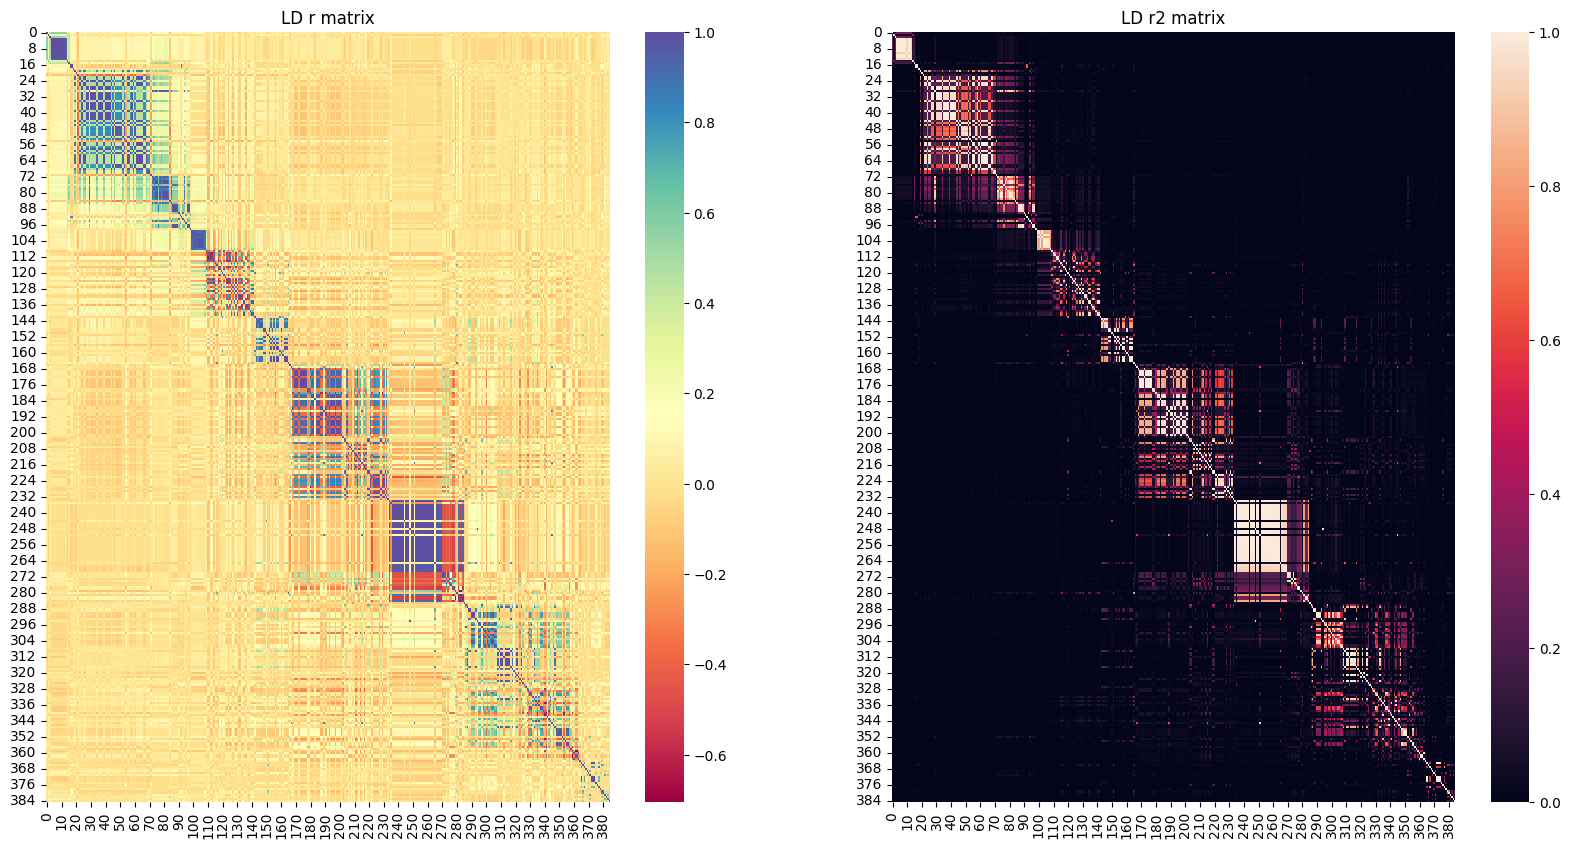

In [ ]:
plt.figure(figsize=(10,10),dpi=200)
fig, ax = plt.subplots(ncols=2,figsize=(20,10))
sns.heatmap(data=R_df,cmap="Spectral",ax=ax[0])
sns.heatmap(data=R_df2,ax=ax[1])
ax[0].set_title("LD r matrix")
ax[1].set_title("LD r2 matrix")

In [ ]:
chr19_45412079_region=pd.read_csv("../../data/susie/UK_Biobank/COL/chr19_45412079_region_snplist.txt", delim_whitespace=False)

/tmp/ipykernel_3582546/2304295073.py:1: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  chr19_45412079_region=pd.read_csv("../../data/susie/UK_Biobank/COL/chr19_45412079_region_snplist.txt", delim_whitespace=False)


In [ ]:
print(chr19_45412079_region.shape)
print(R_df.shape) 

(389, 13)
(385, 385)


In [ ]:
chr19_45412079_region.head()

,SNP,CHR,POS,A1,A2,REF,EAF,Beta,se,P,N,INFO,SNPID
0,rs204540,19,44955698,C,A,C,0.221018,-0.004734,0.000800,1.100000e-08,459324,0.988942,19:44955698:C:A
1,rs143777867,19,44978625,G,A,G,0.985413,0.016085,0.002832,1.900000e-08,459324,0.942950,19:44978625:G:A
2,rs3745148,19,44988716,G,A,G,0.882091,0.006109,0.001027,4.800000e-09,459324,0.993510,19:44988716:G:A
3,rs55644952,19,45007638,G,A,G,0.843719,0.005721,0.000910,7.400000e-10,459324,0.996708,19:45007638:G:A
4,rs55685302,19,45007703,A,G,A,0.843728,0.005729,0.000910,7.100000e-10,459324,0.996716,19:45007703:A:G


## ISSUE:

From the plink result there are SNPS that are found in the gwas data(21001_raw.gwas.imputed_v3.both_sexes) which are missing from the vcf 1000 genomic population data. 

Inorder to see which snps are missing the method i used is

1.only store the SNP column that are found in the merged_data.bim(all chr plink binary files) to available_snps.txt
   `awk '{print $2}' ../data/susie/plink_binary_col/merged_data.bim > ../data/susie/plink_binary_col/available_snps.txt`

2. extract SNPs that are not common from the avaliable_snps and from the current chr16_pos53828066_snps.txt
`grep -vFf ../data/susie/plink_binary_col/available_snps.txt ../data/susie/UK_Biobank/COL/chr19_45412079_region_snplist.txt > ../data/susie/UK_Biobank/COL/missing_snps.txt `


    SNPID   minor_allele    minor_AF        low_confidence_variant  n_complete_samples      AC      ytx     beta   se       tstat   P       CHR     POS     A2      A1
    16:53798630:C:CT        CT      0.115132        False   359983  82890.9 2260270.0       -0.155318       0.0176772       -8.78632        1.55203e-18     16      53798630        C       CT
    16:53799977:T:G G       0.421581        False   359983  303524.0        8371400.0       0.340303        0.0112735       30.1862 6.39588e-200    16      53799977        T       G
    16:53812783:TTTTG:T     T       0.390218        False   359983  280943.0        7751780.0       0.348645       0.01153  30.2382 1.33422e-200    16      53812783        TTTTG   T
    16:53820996:C:G G       0.392556        False   359983  282627.0        7799390.0       0.349687        0.0114009       30.6719 2.49515e-206    16      53820996        C       G

From the result there are total of `4` SNPs which are not included in the ld matrix.
The missing snps are also not found in the original vcf data before it is converted to plink binary files.

The current solution i used is to exclude these snps from the chr16_pos53828066_snps.txt so that to match the shape of the ld_matrix. 

In [ ]:
missing_snps=pd.read_csv("../../data/susie/UK_Biobank/COL/missing_snps.txt", delim_whitespace=False)
missing_snps

/tmp/ipykernel_3582546/2774232186.py:1: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  missing_snps=pd.read_csv("../../data/susie/UK_Biobank/COL/missing_snps.txt", delim_whitespace=False)


,SNP,CHR,POS,A1,A2,REF,EAF,Beta,se,P,N,INFO,SNPID
0,rs4803758,19,45327423,G,T,G,0.676215,-0.008856,0.000706,1.000000e-35,459324,0.996920,19:45327423:G:T
1,rs73052307,19,45384405,T,C,T,0.851599,0.016011,0.000937,2.100000e-66,459324,0.980799,19:45384405:T:C
2,rs9636134,19,45432505,A,T,A,0.633863,-0.005601,0.000778,1.000000e-12,459324,0.772426,19:45432505:A:T
3,rs112170101,19,45505803,G,C,G,0.986574,-0.017407,0.002886,2.600000e-09,459324,0.968304,19:45505803:G:C


In [ ]:
chr19_45412079_region.head()

,SNP,CHR,POS,A1,A2,REF,EAF,Beta,se,P,N,INFO,SNPID
0,rs204540,19,44955698,C,A,C,0.221018,-0.004734,0.000800,1.100000e-08,459324,0.988942,19:44955698:C:A
1,rs143777867,19,44978625,G,A,G,0.985413,0.016085,0.002832,1.900000e-08,459324,0.942950,19:44978625:G:A
2,rs3745148,19,44988716,G,A,G,0.882091,0.006109,0.001027,4.800000e-09,459324,0.993510,19:44988716:G:A
3,rs55644952,19,45007638,G,A,G,0.843719,0.005721,0.000910,7.400000e-10,459324,0.996708,19:45007638:G:A
4,rs55685302,19,45007703,A,G,A,0.843728,0.005729,0.000910,7.100000e-10,459324,0.996716,19:45007703:A:G


In [ ]:
filtered_chr19_45412079_region = chr19_45412079_region[~chr19_45412079_region["POS"].isin(missing_snps["POS"])]

In [ ]:
filtered_chr19_45412079_region.head(1)

,SNP,CHR,POS,A1,A2,REF,EAF,Beta,se,P,N,INFO,SNPID
0,rs204540,19,44955698,C,A,C,0.221018,-0.004734,0.0008,1.100000e-08,459324,0.988942,19:44955698:C:A


## Run finemapping with susieR

In [ ]:
print(R_df.shape)
print(filtered_chr19_45412079_region["Beta"].shape)
print(filtered_chr19_45412079_region["se"].shape)


(385, 385)
(385,)
(385,)


r-2

## Adjusting the LD matrix to be positive semi-definite

In [ ]:
import pandas as pd
ld_r = pd.read_csv("../../data/susie/UK_Biobank/COL/sig_locus_mt.ld", sep="\t", header=None)
R_df = ld_r.values
ld2 = pd.read_csv("../../data/susie/UK_Biobank/COL/sig_locus_mt_r2.ld",sep="\t",header=None)
R_df2 = ld2.values
R_df.shape

(385, 385)

In [ ]:
eigvals = np.linalg.eigvalsh(R_df)
min_eigval = eigvals.min()
print(min_eigval)

-1.7588646433521376e-06


In [ ]:
if min_eigval < 0:
    eps = 0.1
    R_df += np.eye(R_df.shape[0]) * eps


In [ ]:
ro.r('set.seed(321)')
fit = susieR.susie_rss(
    bhat =filtered_chr19_45412079_region["Beta"].values.reshape(len(R_df), 1),
    shat =filtered_chr19_45412079_region["se"].values.reshape(len(R_df), 1),
    R = R_df,
    L = 10,
    n = 457824
)

## Extract credible sets and pip

In [ ]:
credible_sets = susieR.susie_get_cs(fit, coverage=0.95, min_abs_corr=0.5, Xcorr=R_df)
print(credible_sets)

$cs
$cs$L1
[1] 333

$cs$L2
[1] 297

$cs$L3
[1] 301

$cs$L4
[1] 329

$cs$L5
[1] 354

$cs$L6
[1] 338

$cs$L7
[1] 280

$cs$L8
[1] 259 260 261 262 263 264 265

$cs$L9
[1] 173

$cs$L10
[1] 281


$purity
    min.abs.corr mean.abs.corr median.abs.corr
L1             1             1               1
L2             1             1               1
L3             1             1               1
L4             1             1               1
L5             1             1               1
L6             1             1               1
L7             1             1               1
L8             1             1               1
L9             1             1               1
L10            1             1               1

$cs_index
 [1]  1  2  3  4  5  6  7  8  9 10

$coverage
 [1] 1.0000000 1.0000000 1.0000000 1.0000000 1.0000000 0.9999983 1.0000000
 [8] 0.9771434 1.0000000 1.0000000

$requested_coverage
[1] 0.95




In [ ]:
filtered_chr19_45412079_region.head()

,SNP,CHR,POS,A1,A2,REF,EAF,Beta,se,P,N,INFO,SNPID,cs
0,rs204540,19,44955698,C,A,C,0.221018,-0.004734,0.000800,1.100000e-08,459324,0.988942,19:44955698:C:A,0
1,rs143777867,19,44978625,G,A,G,0.985413,0.016085,0.002832,1.900000e-08,459324,0.942950,19:44978625:G:A,0
2,rs3745148,19,44988716,G,A,G,0.882091,0.006109,0.001027,4.800000e-09,459324,0.993510,19:44988716:G:A,0
3,rs55644952,19,45007638,G,A,G,0.843719,0.005721,0.000910,7.400000e-10,459324,0.996708,19:45007638:G:A,0
4,rs55685302,19,45007703,A,G,A,0.843728,0.005729,0.000910,7.100000e-10,459324,0.996716,19:45007703:A:G,0


In [ ]:
filtered_chr19_45412079_region = filtered_chr19_45412079_region.reset_index(drop=True)

In [ ]:

filtered_chr19_45412079_region["cs"] = 0
n_cs = len(susieR.susie_get_cs(fit, coverage = 0.95, min_abs_corr = 0.5, Xcorr = R_df)[0])
print(n_cs)
credible_sets = susieR.susie_get_cs(fit, coverage=0.95, min_abs_corr=0.5, Xcorr=R_df)[0]

for i in range(n_cs):
    cs_index = credible_sets[i]
    filtered_chr19_45412079_region.loc[np.array(cs_index)-1, "cs"] = i + 1

filtered_chr19_45412079_region["pip"] = np.array(susieR.susie_get_pip(fit))

10


In [ ]:
cs_index = np.array(credible_sets[0])
for i in range(1, n_cs):
    cs_index = np.concatenate((cs_index, np.array(credible_sets[i])), axis=0)
credible_snps = filtered_chr19_45412079_region.loc[cs_index - 1, :]

print(credible_snps)

            SNP  CHR       POS A1 A2 REF       EAF      Beta        se  \
332      rs7412   19  45412079  C  T   C  0.919760  0.039020  0.001216   
296      rs6857   19  45392254  C  T   C  0.829353 -0.025536  0.000880   
300    rs157580   19  45395266  G  A   G  0.394681 -0.012784  0.000675   
328    rs405509   19  45408836  T  G   T  0.488613  0.006784  0.000661   
353    rs157595   19  45425460  A  G   A  0.383731 -0.012011  0.000696   
337  rs10414043   19  45415713  G  A   G  0.873116 -0.026815  0.000995   
279      rs6859   19  45382034  A  G   A  0.421672  0.009146  0.000668   
258    rs416116   19  45366345  G  A   G  0.624106 -0.005142  0.000682   
259    rs403729   19  45366410  G  C   G  0.623344 -0.005116  0.000682   
260    rs521629   19  45366603  G  A   G  0.623322 -0.005107  0.000682   
261    rs520566   19  45366656  G  A   G  0.623321 -0.005108  0.000682   
262    rs519825   19  45366779  T  C   T  0.623322 -0.005113  0.000682   
263    rs376938   19  45366830  A  G  

In [ ]:
credible_snps_sorted = credible_snps.sort_values(by="pip", ascending=False)
print(credible_snps_sorted[["SNPID", "pip"]])

               SNPID       pip
332  19:45412079:C:T  1.000000
296  19:45392254:C:T  1.000000
300  19:45395266:G:A  1.000000
328  19:45408836:T:G  1.000000
353  19:45425460:A:G  1.000000
279  19:45382034:A:G  1.000000
280  19:45382675:G:A  1.000000
172  19:45327459:T:C  1.000000
337  19:45415713:G:A  0.999998
258  19:45366345:G:A  0.531024
264  19:45368082:C:A  0.097683
259  19:45366410:G:C  0.093402
263  19:45366830:A:G  0.079989
262  19:45366779:T:C  0.073285
261  19:45366656:G:A  0.053838
260  19:45366603:G:A  0.047923


In [ ]:
import requests


chrom =credible_snps_sorted["CHR"]
pos =credible_snps_sorted["POS"]
pip =credible_snps_sorted["pip"]
crediable_snps_rs = []

def get_rsid(chrom, pos, genome="hg19"):
    url = f"https://api.genome.ucsc.edu/getData/track?genome={genome};track=dbSnp155;chrom=chr{chrom};start={pos-1};end={pos}"
    response = requests.get(url).json()
    if "dbSnp155" in response and response["dbSnp155"]:
        return response["dbSnp155"][0]["name"]
    return None

for c, p, pip in zip(chrom, pos, pip):
    rsid = get_rsid(c, p)
    crediable_snps_rs.append([rsid, c, p, pip])

df_crediable_snps= pd.DataFrame(crediable_snps_rs, columns=["rsID", "Chromosome", "Position", "pip"])



In [ ]:
df_crediable_snps[["rsID", "pip"]]

,rsID,pip
0,rs7412,1.000000
1,rs6857,1.000000
2,rs377239666,1.000000
3,rs1201564081,1.000000
4,rs157595,1.000000
5,rs6859,1.000000
6,rs41290120,1.000000
7,rs4803759,1.000000
8,rs10414043,0.999998
9,rs416116,0.531024


## Create regional plot

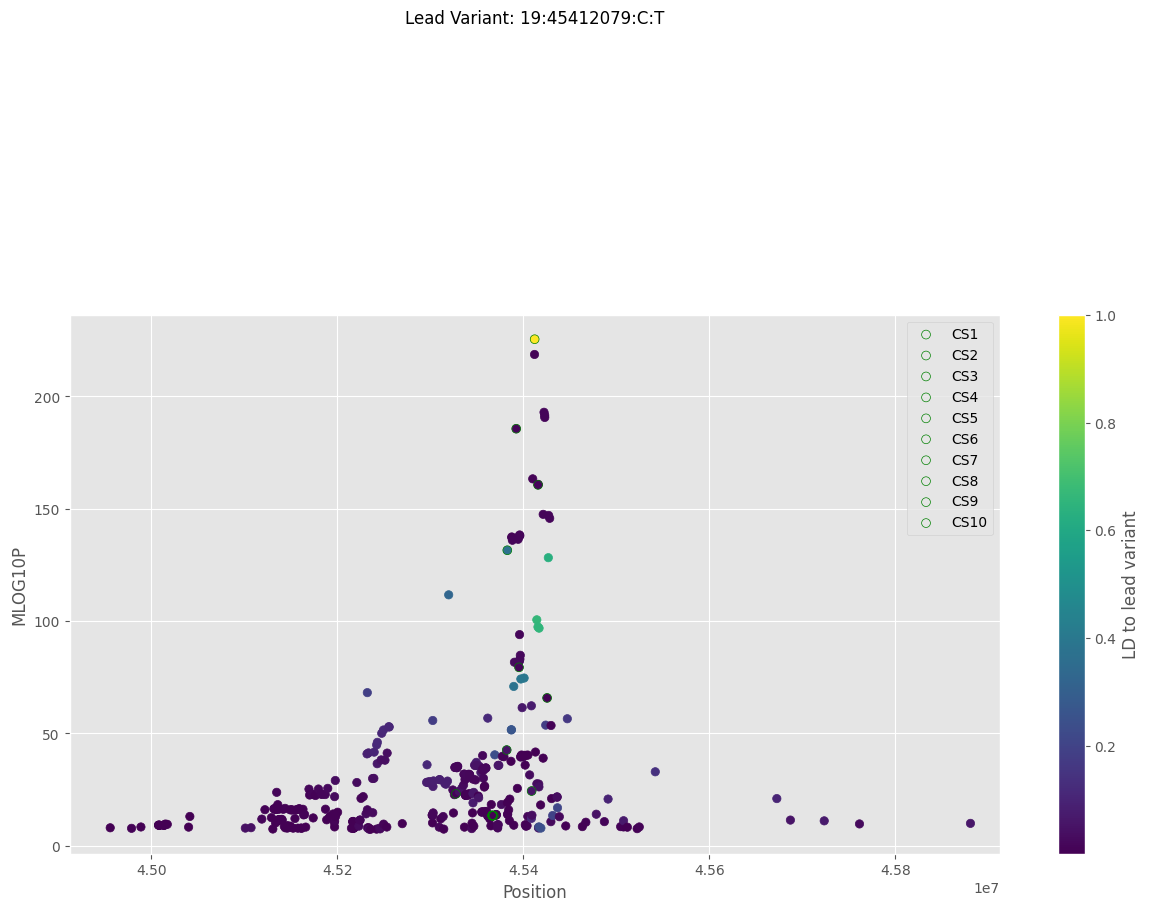

In [ ]:
plt.style.use("ggplot")
fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(15, 7))

col_to_plot = "MLOG10P"
filtered_chr19_45412079_region[col_to_plot] = -np.log10(filtered_chr19_45412079_region["P"].replace(0, np.nan))

p = ax.scatter(
    filtered_chr19_45412079_region["POS"], 
    filtered_chr19_45412079_region[col_to_plot], 
    c=ld2[filtered_chr19_45412079_region["P"].idxmin()]
)

lead_x = filtered_chr19_45412079_region.loc[filtered_chr19_45412079_region["P"].idxmin(), "POS"]
lead_y = filtered_chr19_45412079_region.loc[filtered_chr19_45412079_region["P"].idxmin(), col_to_plot]

ax.annotate(
    f"Lead Variant: {filtered_chr19_45412079_region.loc[filtered_chr19_45412079_region['P'].idxmin(), 'SNPID']}", 
    (lead_x, lead_y), 
    textcoords="offset points", xytext=(0, lead_y + 2), ha='center', fontsize=12
)

credible_sets = susieR.susie_get_cs(fit, coverage=0.95, min_abs_corr=0.5, Xcorr=R_df)[0]
n_cs = len(credible_sets)

for i in range(n_cs):
    cs_index = credible_sets[i]
    pos = filtered_chr19_45412079_region.loc[np.array(cs_index) - 1, "POS"]
    y = filtered_chr19_45412079_region.loc[np.array(cs_index) - 1, col_to_plot]
    ax.scatter(pos, y, marker='o', s=40, label=f"CS{i+1}", edgecolors="green", facecolors="none")

plt.colorbar(p, label="LD to lead variant")
ax.set_xlabel("Position")
ax.set_ylabel(col_to_plot)
ax.set_xlim((44912079, 45912079))
plt.legend()
plt.show()


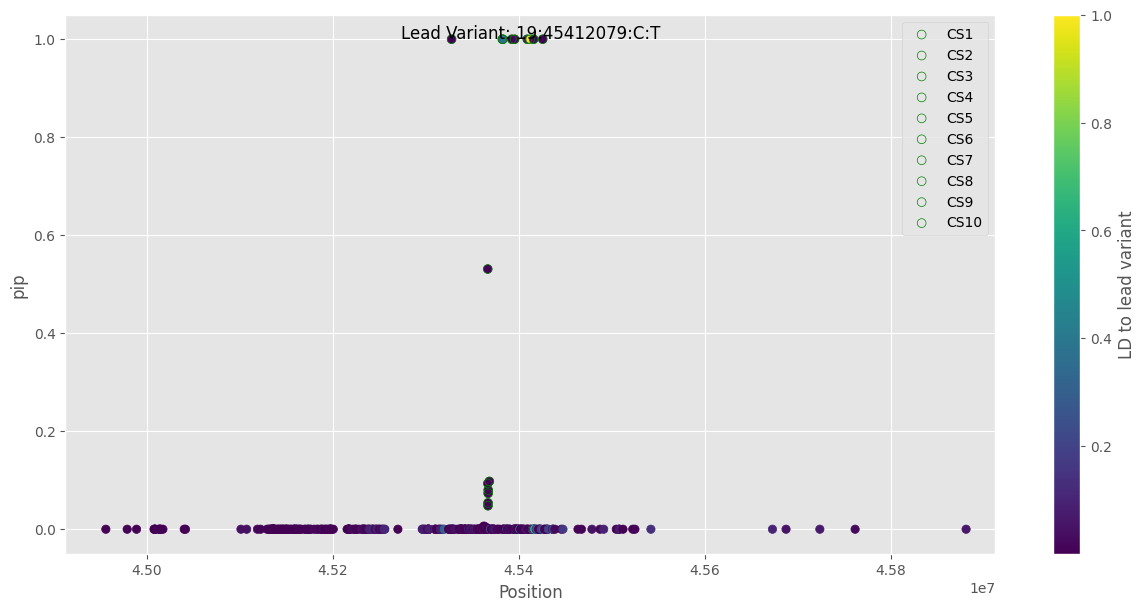

In [ ]:
plt.style.use("ggplot")
fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(15, 7))

col_to_plot = "pip"
p = ax.scatter(
    filtered_chr19_45412079_region["POS"], 
    filtered_chr19_45412079_region[col_to_plot], 
    c=ld2[filtered_chr19_45412079_region["P"].idxmin()]
)

lead_x = filtered_chr19_45412079_region.loc[filtered_chr19_45412079_region["P"].idxmin(), "POS"]
lead_y = filtered_chr19_45412079_region.loc[filtered_chr19_45412079_region["P"].idxmin(), col_to_plot]

ax.annotate(
    f"Lead Variant: {filtered_chr19_45412079_region.loc[filtered_chr19_45412079_region['P'].idxmin(), 'SNPID']}", 
    (lead_x, lead_y), 
    textcoords="offset points", xytext=(0, lead_y + 0.02), ha='center', fontsize=12
)

credible_sets = susieR.susie_get_cs(fit, coverage=0.95, min_abs_corr=0.5, Xcorr=R_df)[0]
n_cs = len(credible_sets)

for i in range(n_cs):
    cs_index = credible_sets[i]
    pos = filtered_chr19_45412079_region.loc[np.array(cs_index) - 1, "POS"]
    y = filtered_chr19_45412079_region.loc[np.array(cs_index) - 1, col_to_plot]
    
    ax.scatter(pos, y, marker='o', s=40, label=f"CS{i+1}", edgecolors="green", facecolors="none")

plt.colorbar(p, label="LD to lead variant")
ax.set_xlabel("Position")
ax.set_ylabel(col_to_plot)
ax.set_xlim((44912079, 45912079))
# ax.set_ylim((0, 0.1))
plt.legend()
plt.show()
